<a href="https://colab.research.google.com/github/Deepakmittal03/Website_Traffic_Analysis/blob/main/Website_Traffic_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape : (226278, 9)

Columns:
Index(['event', 'date', 'country', 'city', 'artist', 'album', 'track', 'isrc',
       'linkid'],
      dtype='object')

Missing Values:
event         0
date          0
country      11
city         11
artist       37
album         5
track         5
isrc       7121
linkid        0
dtype: int64

Data Types:
event      object
date       object
country    object
city       object
artist     object
album      object
track      object
isrc       object
linkid     object
dtype: object

Summary Statistics:
           event        date       country    city  artist        album  \
count     226278      226278        226267  226267  226241       226273   
unique         3           7           211   11993    2419         3254   
top     pageview  2021-08-19  Saudi Arabia  Jeddah  Tesher  Jalebi Baby   
freq      142015       35361         47334   22791   40841        40841   

              track          isrc                                linkid  
count    

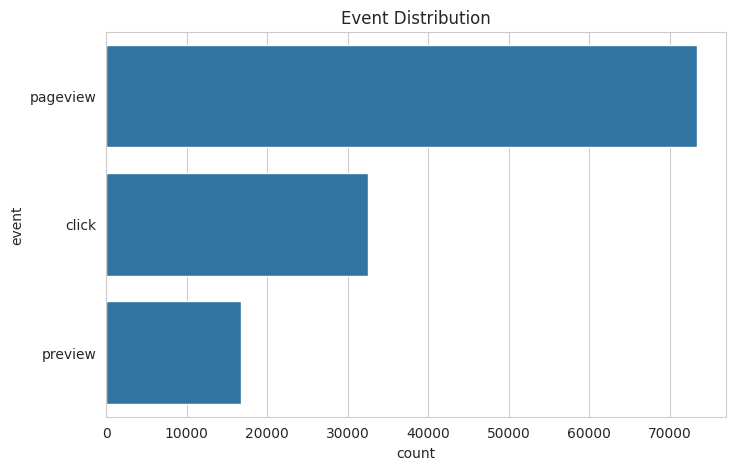

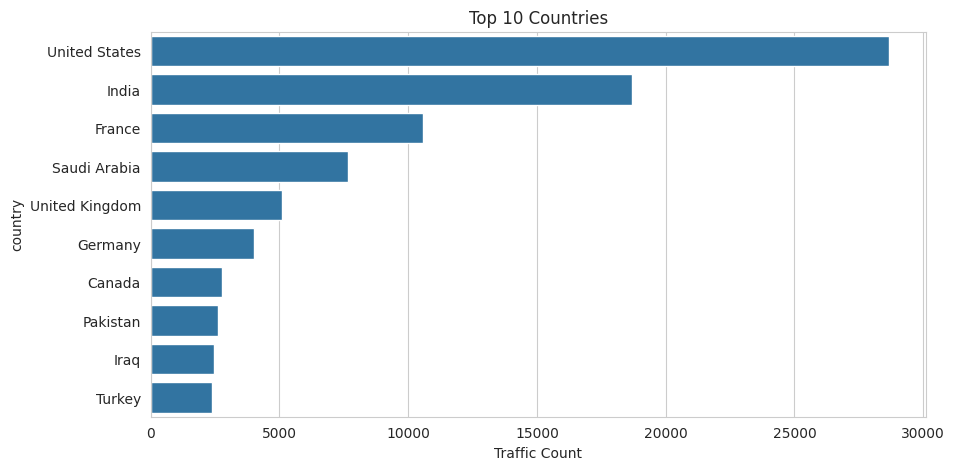

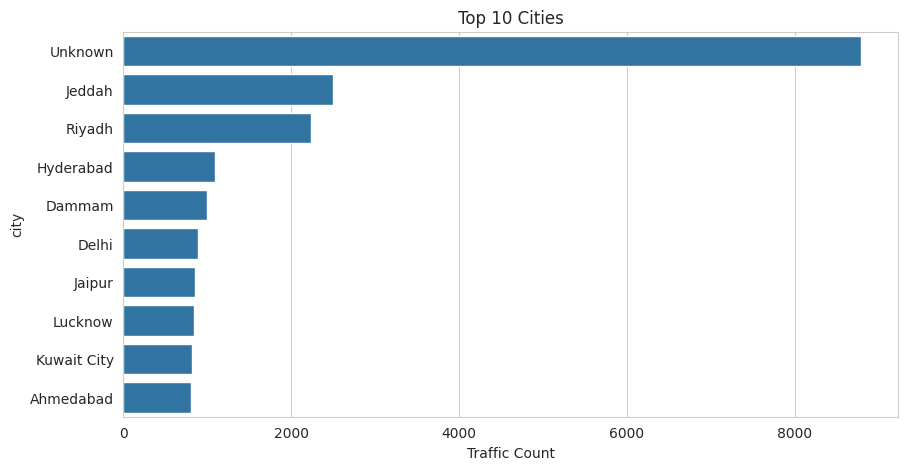

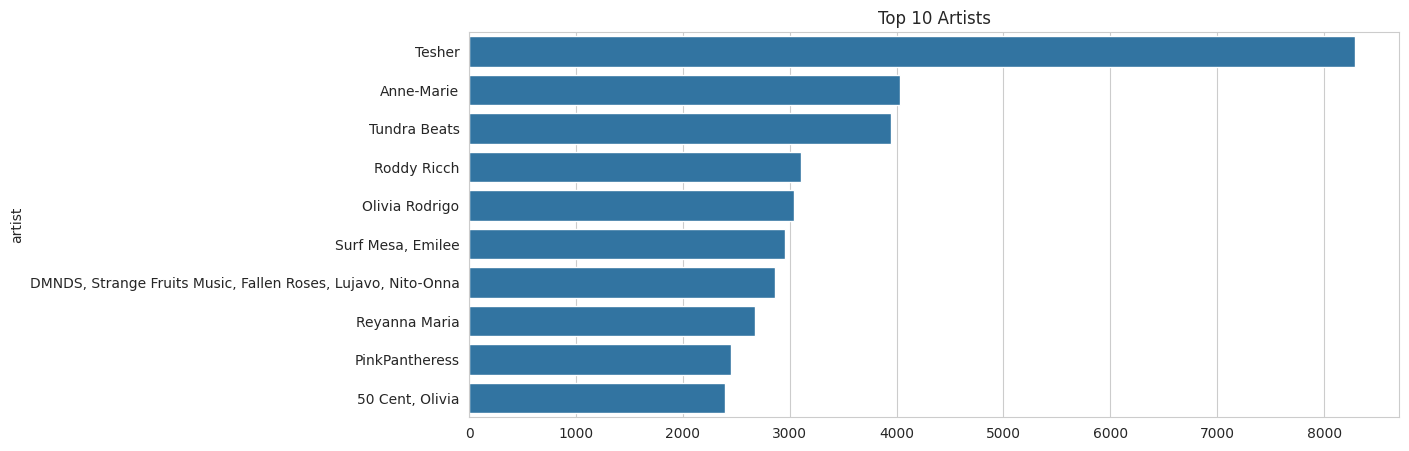

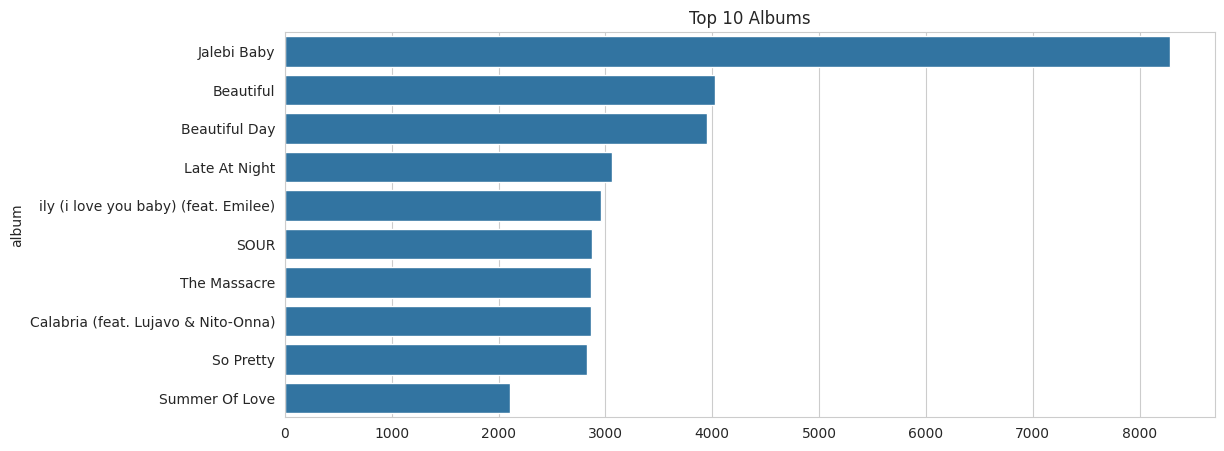

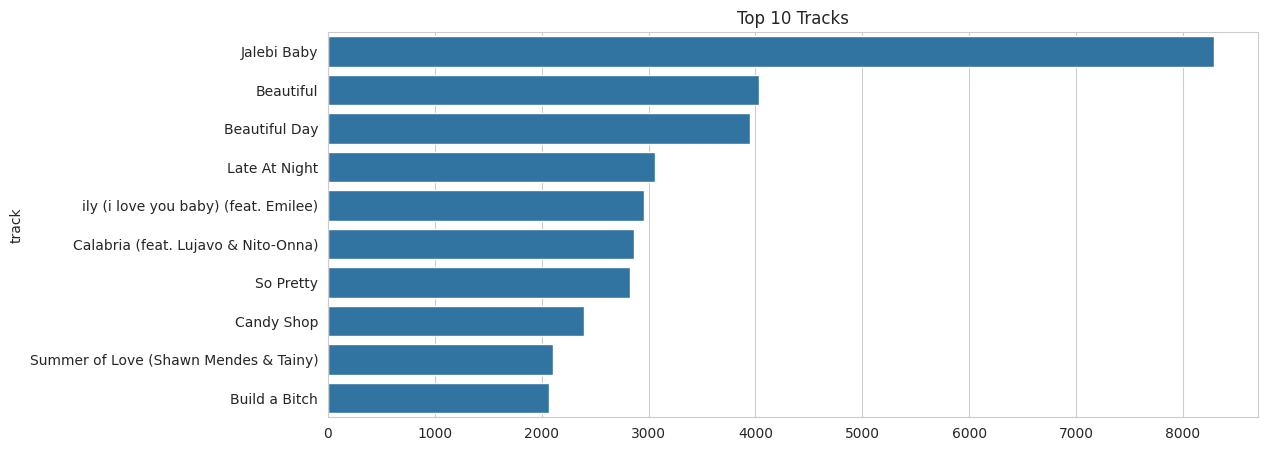

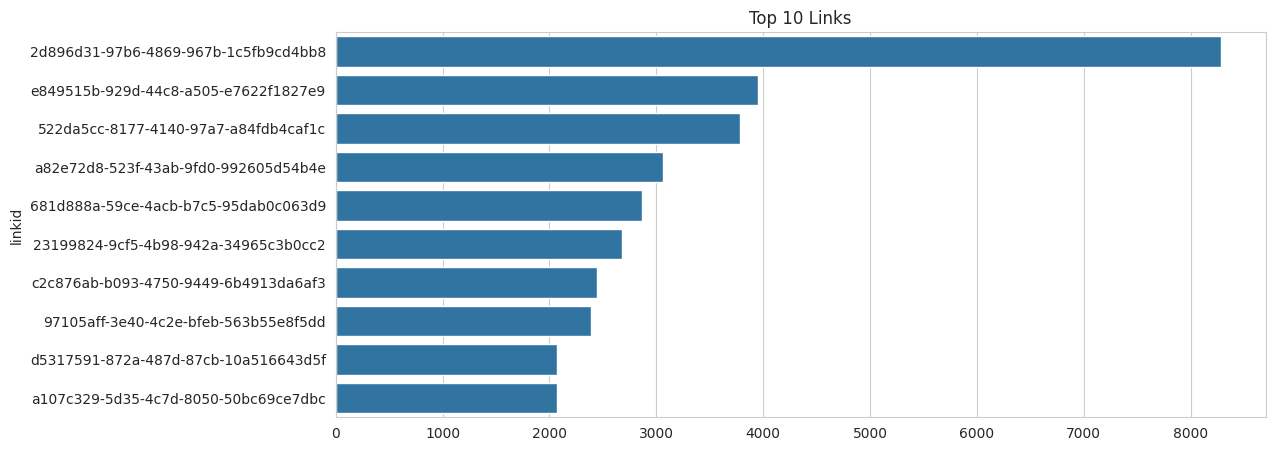

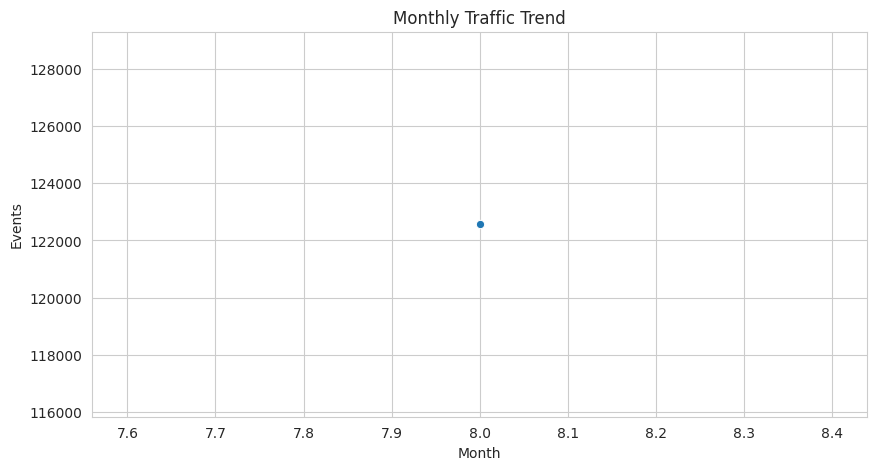


========== NUMPY ANALYSIS ==========

========== BUSINESS INSIGHTS ==========
✔ Identified top countries generating traffic
✔ Identified top cities generating traffic
✔ Discovered most popular artists and tracks
✔ Evaluated link performance
✔ Analyzed traffic trends over time
✔ Generated data-driven recommendations


In [1]:
# ======================================
# TRAFFIC DATA ANALYSIS PROJECT
# ======================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

# ======================================
# LOAD DATASET
# ======================================

df = pd.read_csv("/content/traffic.csv")

# ======================================
# BASIC EXPLORATION
# ======================================

print("Dataset Shape :", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

print("\nSummary Statistics:")
print(df.describe(include='all'))

# ======================================
# DATA CLEANING
# ======================================

df.drop_duplicates(inplace=True)

print("\nShape After Removing Duplicates:")
print(df.shape)

# ======================================
# EVENT DISTRIBUTION
# ======================================

if 'event' in [c.lower() for c in df.columns]:

    event_col = [c for c in df.columns if c.lower() == 'event'][0]

    plt.figure(figsize=(8,5))
    sns.countplot(y=event_col,
                  data=df,
                  order=df[event_col].value_counts().index)

    plt.title("Event Distribution")
    plt.show()

# ======================================
# TOP 10 COUNTRIES
# ======================================

country_col = [c for c in df.columns if 'country' in c.lower()]

if country_col:

    top_country = (
        df[country_col[0]]
        .value_counts()
        .head(10)
    )

    plt.figure(figsize=(10,5))
    sns.barplot(
        x=top_country.values,
        y=top_country.index
    )

    plt.title("Top 10 Countries")
    plt.xlabel("Traffic Count")
    plt.show()

# ======================================
# TOP 10 CITIES
# ======================================

city_col = [c for c in df.columns if 'city' in c.lower()]

if city_col:

    top_city = (
        df[city_col[0]]
        .value_counts()
        .head(10)
    )

    plt.figure(figsize=(10,5))
    sns.barplot(
        x=top_city.values,
        y=top_city.index
    )

    plt.title("Top 10 Cities")
    plt.xlabel("Traffic Count")
    plt.show()

# ======================================
# TOP ARTISTS
# ======================================

artist_col = [c for c in df.columns if 'artist' in c.lower()]

if artist_col:

    top_artist = (
        df[artist_col[0]]
        .value_counts()
        .head(10)
    )

    plt.figure(figsize=(12,5))
    sns.barplot(
        x=top_artist.values,
        y=top_artist.index
    )

    plt.title("Top 10 Artists")
    plt.show()

# ======================================
# TOP ALBUMS
# ======================================

album_col = [c for c in df.columns if 'album' in c.lower()]

if album_col:

    top_album = (
        df[album_col[0]]
        .value_counts()
        .head(10)
    )

    plt.figure(figsize=(12,5))
    sns.barplot(
        x=top_album.values,
        y=top_album.index
    )

    plt.title("Top 10 Albums")
    plt.show()

# ======================================
# TOP TRACKS
# ======================================

track_col = [c for c in df.columns if 'track' in c.lower()]

if track_col:

    top_track = (
        df[track_col[0]]
        .value_counts()
        .head(10)
    )

    plt.figure(figsize=(12,5))
    sns.barplot(
        x=top_track.values,
        y=top_track.index
    )

    plt.title("Top 10 Tracks")
    plt.show()

# ======================================
# LINK PERFORMANCE
# ======================================

link_col = [c for c in df.columns if 'link' in c.lower()]

if link_col:

    top_links = (
        df[link_col[0]]
        .value_counts()
        .head(10)
    )

    plt.figure(figsize=(12,5))
    sns.barplot(
        x=top_links.values,
        y=top_links.index
    )

    plt.title("Top 10 Links")
    plt.show()

# ======================================
# DATE ANALYSIS
# ======================================

date_col = [c for c in df.columns if 'date' in c.lower()]

if date_col:

    df[date_col[0]] = pd.to_datetime(
        df[date_col[0]],
        errors='coerce'
    )

    monthly_traffic = (
        df.groupby(
            df[date_col[0]].dt.month
        ).size()
    )

    plt.figure(figsize=(10,5))
    sns.lineplot(
        x=monthly_traffic.index,
        y=monthly_traffic.values,
        marker='o'
    )

    plt.title("Monthly Traffic Trend")
    plt.xlabel("Month")
    plt.ylabel("Events")
    plt.show()

# ======================================
# NUMPY ANALYSIS
# ======================================

print("\n========== NUMPY ANALYSIS ==========")

for col in df.select_dtypes(include=np.number).columns:

    arr = np.array(df[col])

    print(f"\nColumn: {col}")
    print("Mean :", np.mean(arr))
    print("Median :", np.median(arr))
    print("Max :", np.max(arr))
    print("Min :", np.min(arr))
    print("Std Dev :", np.std(arr))

# ======================================
# CORRELATION HEATMAP
# ======================================

numeric_df = df.select_dtypes(include=np.number)

if numeric_df.shape[1] > 1:

    plt.figure(figsize=(10,6))
    sns.heatmap(
        numeric_df.corr(),
        annot=True,
        cmap="coolwarm"
    )

    plt.title("Correlation Heatmap")
    plt.show()

# ======================================
# BUSINESS INSIGHTS
# ======================================

print("\n========== BUSINESS INSIGHTS ==========")
print("✔ Identified top countries generating traffic")
print("✔ Identified top cities generating traffic")
print("✔ Discovered most popular artists and tracks")
print("✔ Evaluated link performance")
print("✔ Analyzed traffic trends over time")
print("✔ Generated data-driven recommendations")